## * 시각화
* 그래프를 이용하면 데이터의 구조와 패턴을 파악하기 용이하다
* 다양한 관점에서 데이터에 관한 통찰력을 제공한다

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('./inout_pop.xlsx', fillna=0, header=0)
df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226,7297099,7104398
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937,1439707,1426493
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,519334,508043,461042,478451,485710,507031,459015,439073,416095,411704
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,370817,370563,348642,351873,350213,351424,328228,321182,321158,312419


In [2]:
df = df.fillna(method='ffill')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]

# '전출지별'컬럼을 지운다 axis=1은 컬럼방향으로 지운다는 뜻
df_seoul = df_seoul.drop(['전출지별'], axis=1)
# '전입지별' 컬럼이름을 '전입지'로 바꾼다
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
# '전입지'를 인덱스로 만든다
df_seoul.set_index('전입지', inplace=True)
df_seoul.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423,1549937,1476081
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17418,18816,16135,16153,17320,17009,15062,14484,13093,12805
대구광역시,-,-,-,-,-,-,-,-,-,-,...,10277,10397,10135,10631,10062,10191,9623,8891,8446,7897
인천광역시,-,-,-,-,-,-,-,-,-,-,...,46082,51641,49640,47424,43212,44915,43745,40485,41233,38571
광주광역시,-,-,-,-,-,-,-,-,-,-,...,11095,10587,10154,9129,9759,9216,8354,7932,7378,7014


In [3]:
sr_one = df_seoul.loc['경기도']
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

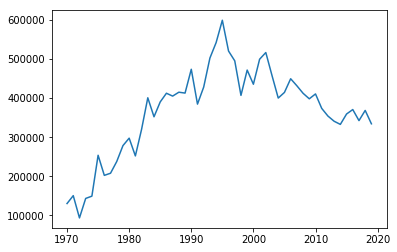

In [4]:
plt.plot(sr_one.index, sr_one.values)  # plt.plot(sr_one) 과도 같다.

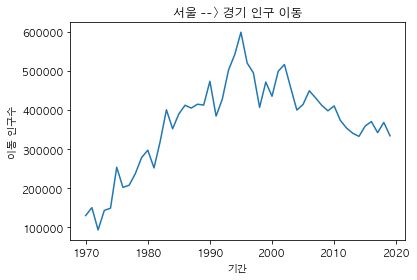

In [5]:
from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

plt.plot(sr_one.index, sr_one.values)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.show()

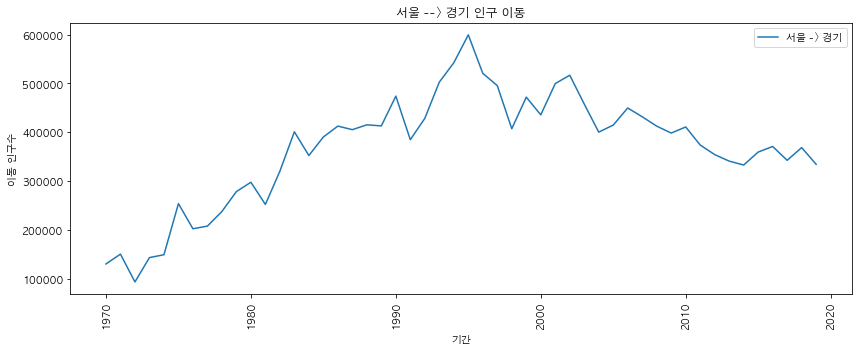

In [6]:
from matplotlib import font_manager, rc
rc('font', family='AppleGothic')

plt.figure(figsize=(14,5))  # 가로사이즈 늘리고
plt.xticks(rotation='vertical') # 눈금 라벨 회전, 90으로 입력해도 된다

plt.plot(sr_one.index, sr_one.values)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best') #범례
plt.show()




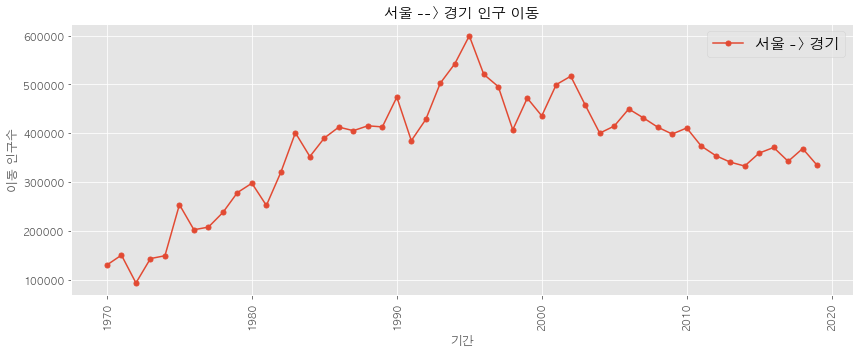

In [7]:
from matplotlib import rc
rc('font', family='AppleGothic')

# 여러가지 스타일:https://matplotlib.org/gallery/style_sheets/style_sheets_reference.html
plt.style.use('ggplot')

plt.figure(figsize=(14,5))  # 가로사이즈 늘리고
plt.xticks(size=10, rotation='vertical') # 눈금 라벨 회전, 90으로 입력해도 된다

plt.plot(sr_one.index, sr_one.values, marker='o', markersize=5)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15) #범례
plt.show()


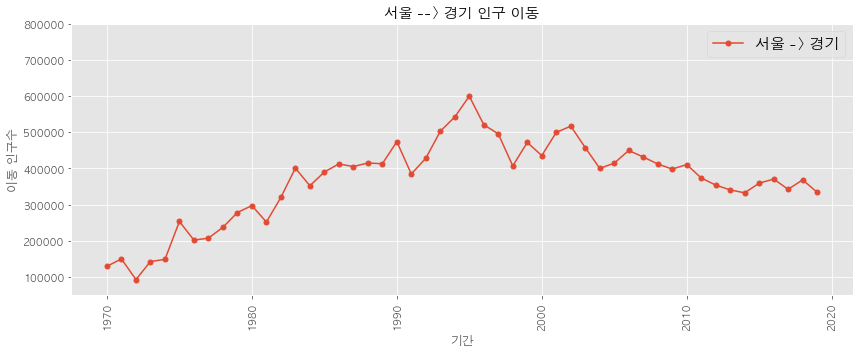

In [8]:
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')

plt.figure(figsize=(14,5))  # 가로사이즈 늘리고
plt.xticks(size=10, rotation='vertical') # 눈금 라벨 회전, 90으로 입력해도 된다

plt.plot(sr_one.index, sr_one.values, marker='o', markersize=5)
plt.title('서울 --> 경기 인구 이동')

plt.xlabel('기간')
plt.ylabel('이동 인구수')

plt.legend(labels=['서울 -> 경기'], loc='best', fontsize=15) #범례

plt.ylim(50000, 800000)  # y축을 늘린다
# 이하 주석 코드는 에러가 난다.
# plt.annotate('',
#             xy=(47, 450000),    #  화살표 머리
#             xytext=(30, 580000), #  화살표 꼬리
#             xycoords='data',
#             arrowprops=dict(arrowstyle='->', color='skyblue', lw=5),
#             )
plt.show()

In [9]:
sr_one.index

Index(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019'],
      dtype='object')

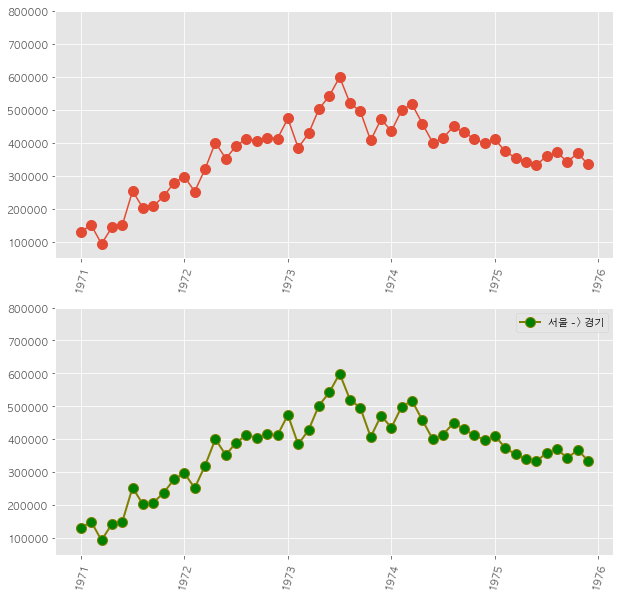

In [10]:
# 화면 분할하기 add_subplot(2행, 1열, 순서)
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')

fig = plt.figure(figsize=(10,10))  # figure: 그림틀을 만든다.
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)

ax1.plot(sr_one.index, sr_one.values, marker='o', markersize=10)
ax2.plot(sr_one.index, sr_one.values, marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 경기')
ax2.legend(loc='best')

# plt는 ylim이었는데 ax1은 set_ylim이다.
ax1.set_ylim(50000, 800000)  
ax2.set_ylim(50000, 800000) 

# plt는 xticks이었는데 ax1은 set_xticklabels이다.
ax1.set_xticklabels(sr_one.index, rotation='75') # 윈도우에서 돌려보자
ax2.set_xticklabels(sr_one.index, rotation='75')

plt.show()

## 선 그래프 꾸미기 옵션
| 꾸미기 옵션 | 설명 |
| ----
| marker | 'o', '*', '+' ,'-' | 

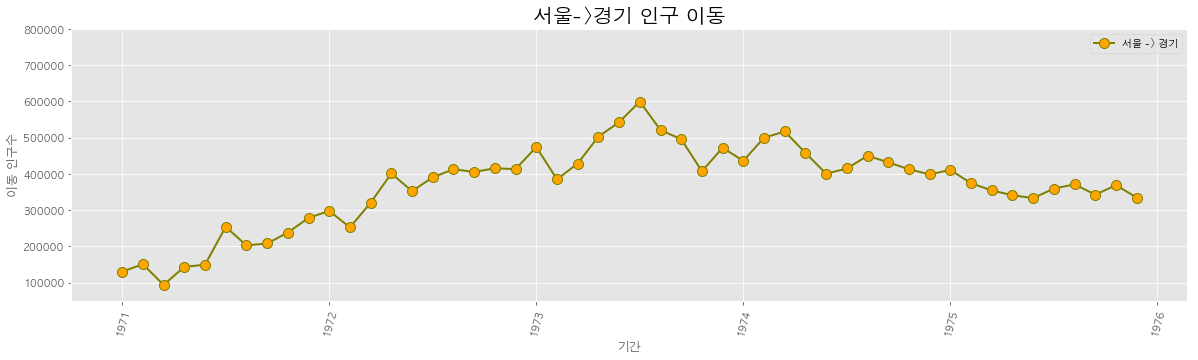

In [11]:
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(sr_one, marker='o', markerfacecolor='orange', markersize=10,
        color='olive', linewidth=2, label='서울 -> 경기')
ax.legend(loc='best')

ax.set_ylim(50000, 800000) 

ax.set_title('서울->경기 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticklabels(sr_one.index, rotation='75')

# 축 눈금 라벨 크기
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

## 같은 화면에 그래프 추가

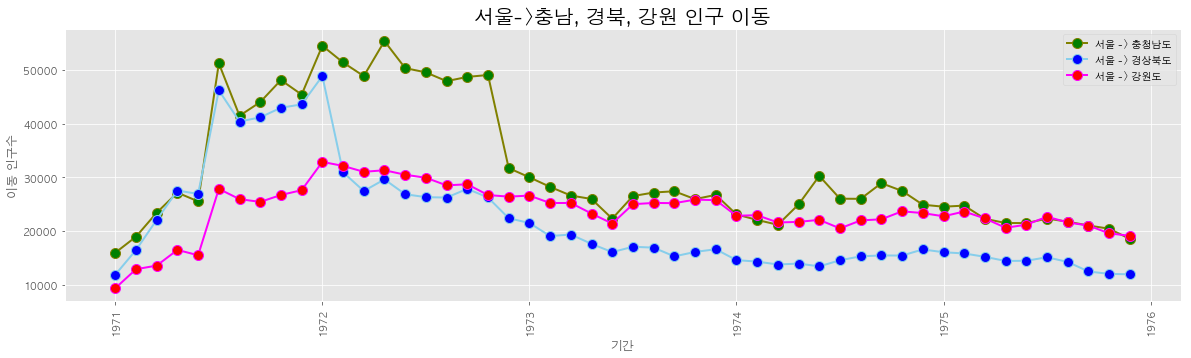

In [12]:
from matplotlib import rc
rc('font', family='AppleGothic')

col_years = list(map(str, range(1970, 2020)))
df_3 = df_seoul.loc[['충청남도','경상북도','강원도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(col_years, df_3.loc['충청남도', :], marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 충청남도')
ax.plot(col_years, df_3.loc['경상북도', :], marker='o', markerfacecolor='blue', markersize=10,
        color='skyblue', linewidth=2, label='서울 -> 경상북도')
ax.plot(col_years, df_3.loc['강원도', :], marker='o', markerfacecolor='red', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 강원도')

ax.legend(loc='best')

ax.set_title('서울->충남, 경북, 강원 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticklabels(col_years, rotation='90')

# 축 눈금 라벨 크기
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

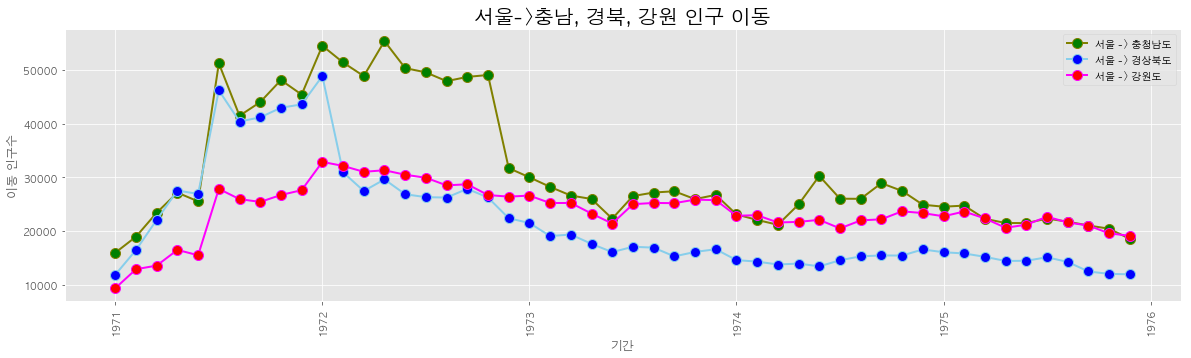

In [13]:
from matplotlib import rc
rc('font', family='AppleGothic')

col_years = list(map(str, range(1970, 2020)))
df_3 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(1,1,1)

ax.plot(col_years, df_3.loc['충청남도', :], marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 충청남도')
ax.plot(col_years, df_3.loc['경상북도', :], marker='o', markerfacecolor='blue', markersize=10,
        color='skyblue', linewidth=2, label='서울 -> 경상북도')
ax.plot(col_years, df_3.loc['강원도', :], marker='o', markerfacecolor='red', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 강원도')

ax.legend(loc='best')

ax.set_title('서울->충남, 경북, 강원 인구 이동', size=20)
ax.set_xlabel('기간', size=12)
ax.set_ylabel('이동 인구수', size=12)

ax.set_xticklabels(col_years, rotation='90')

# 축 눈금 라벨 크기
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.show()

In [14]:
ax.set_xticklabels(col_years, rotation='90')

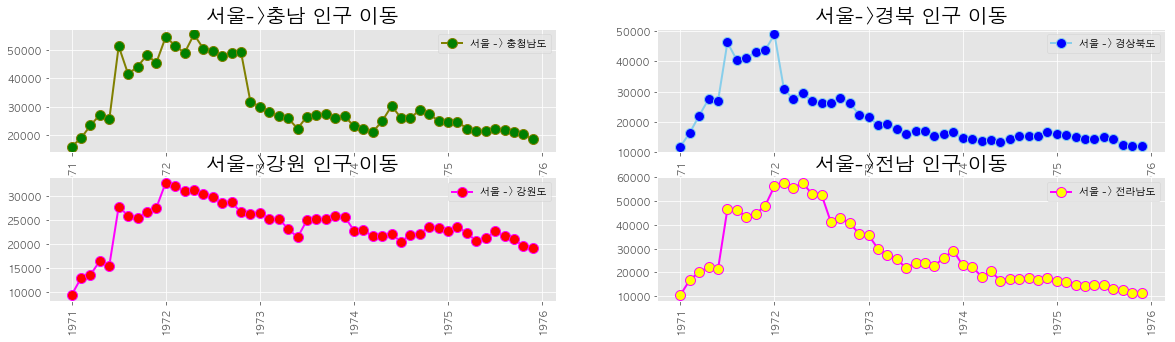

In [15]:
from matplotlib import rc
rc('font', family='AppleGothic')

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]

plt.style.use('ggplot')

fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(2,2,1)
ax2 = fig.add_subplot(2,2,2)
ax3 = fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

ax1.plot(col_years, df_4.loc['충청남도', :], marker='o', markerfacecolor='green', markersize=10,
        color='olive', linewidth=2, label='서울 -> 충청남도')
ax2.plot(col_years, df_4.loc['경상북도', :], marker='o', markerfacecolor='blue', markersize=10,
        color='skyblue', linewidth=2, label='서울 -> 경상북도')
ax3.plot(col_years, df_4.loc['강원도', :], marker='o', markerfacecolor='red', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 강원도')
ax4.plot(col_years, df_4.loc['전라남도', :], marker='o', markerfacecolor='yellow', markersize=10,
        color='magenta', linewidth=2, label='서울 -> 전라남도')

ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax4.legend(loc='best')

ax1.set_title('서울->충남 인구 이동', size=20)
ax2.set_title('서울->경북 인구 이동', size=20)
ax3.set_title('서울->강원 인구 이동', size=20)
ax4.set_title('서울->전남 인구 이동', size=20)

ax1.set_xticklabels(col_years, rotation='90')
ax2.set_xticklabels(col_years, rotation='90')
ax3.set_xticklabels(col_years, rotation='90')
ax4.set_xticklabels(col_years, rotation='90')

plt.show()

## 면적그래프 그리기

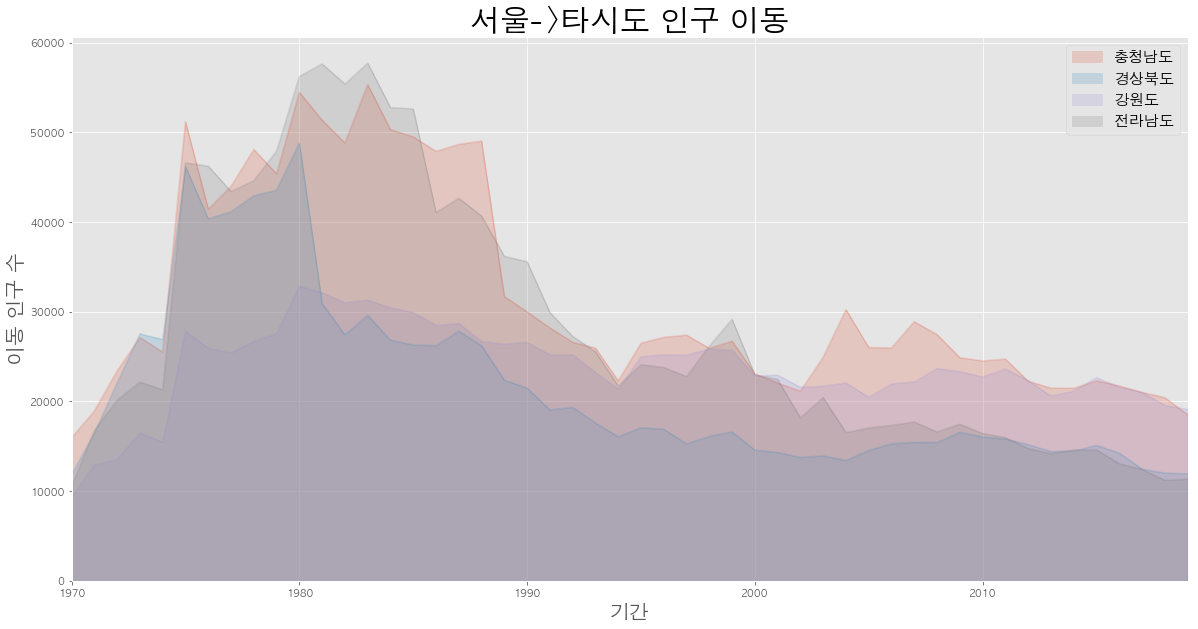

In [16]:
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

df_4.plot(kind='area', stacked=False, alpha=0.2, figsize=(20,10))

plt.title('서울->타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)

plt.show()

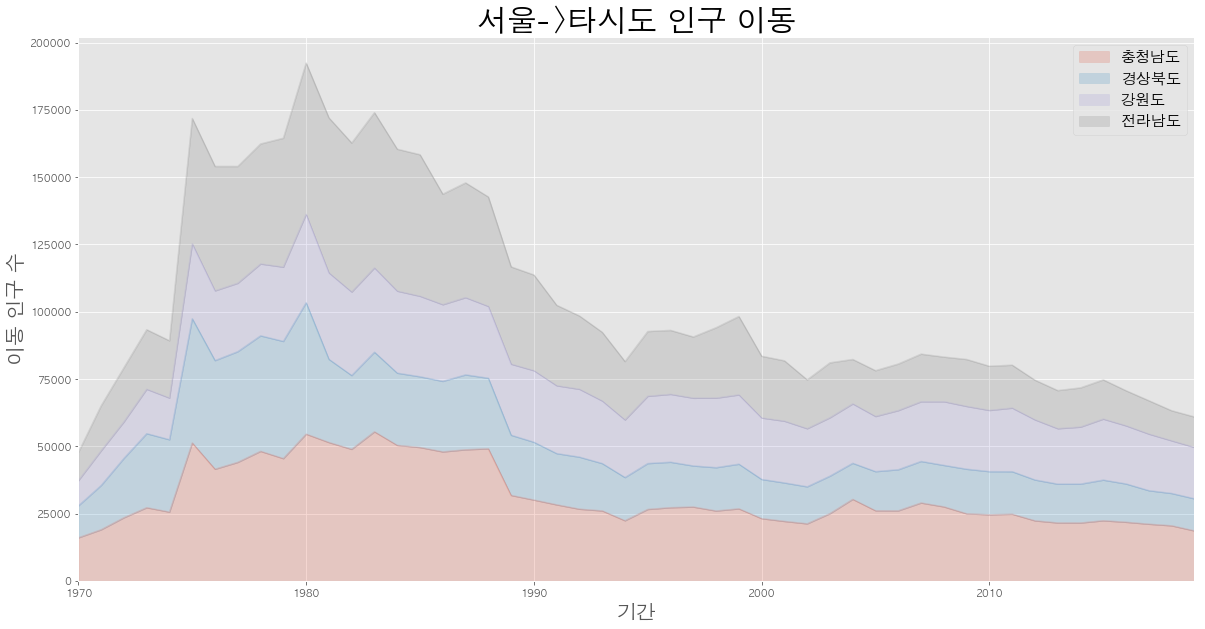

In [17]:
# 겹쳐 그리기 (누적) stacked=True
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20,10))

plt.title('서울->타시도 인구 이동', size=30)
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.legend(loc='best', fontsize=15)

plt.show()

<class 'matplotlib.axes._subplots.AxesSubplot'>


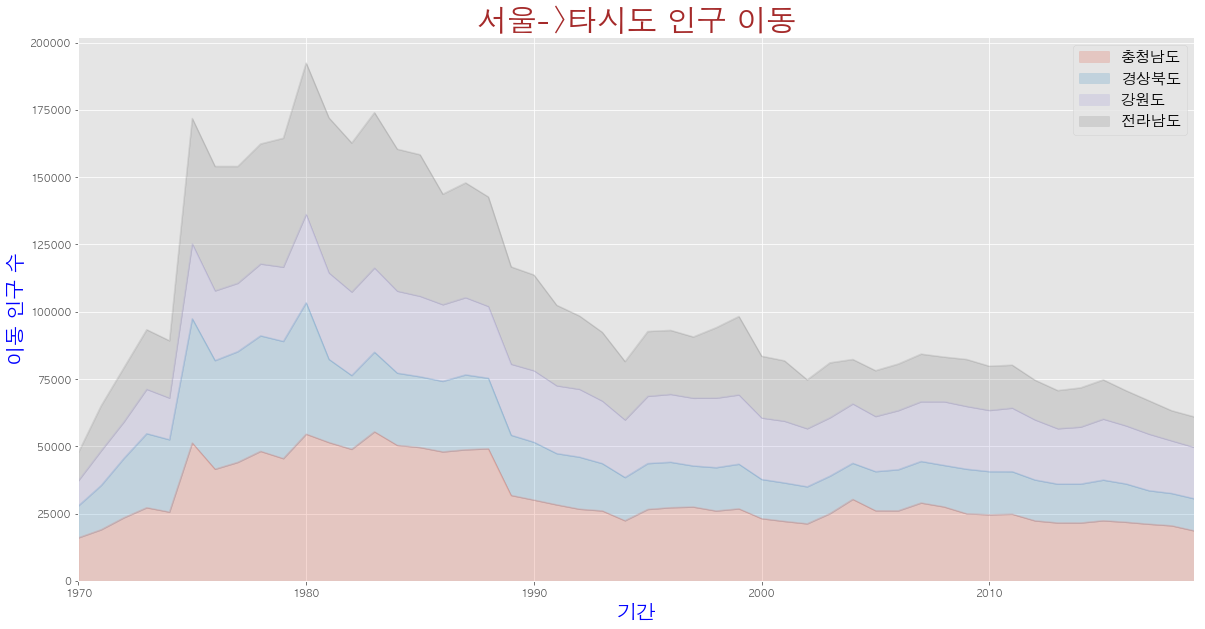

In [18]:
# axe 객체 속성 변경하기 
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

col_years = list(map(str, range(1970, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

# df_4.plot을 통해 ax객체를 받아온다.
ax = df_4.plot(kind='area', stacked=True, alpha=0.2, figsize=(20,10))
print(type(ax))

ax.set_title('서울->타시도 인구 이동', size=30, color='brown', weight='bold')
ax.set_ylabel('이동 인구 수', size=20, color='blue')
ax.set_xlabel('기간', size=20, color='blue')
ax.legend(loc='best', fontsize=15)

plt.show()

# 막대 그래프 그리기

In [19]:
df_seoul.loc[['충청남도','경상북도','강원도','전라남도']]

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,24522,24723,22269,21486,21473,22299,21741,21020,20426,18522
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,16042,15818,15191,14420,14456,15113,14236,12464,12017,11935
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,22736,23624,22332,20601,21173,22659,21590,21016,19558,19105
전라남도,10513,16755,20157,22160,21314,46610,46251,43430,44624,47934,...,16429,15974,14765,14187,14591,14598,13065,12426,11209,11334


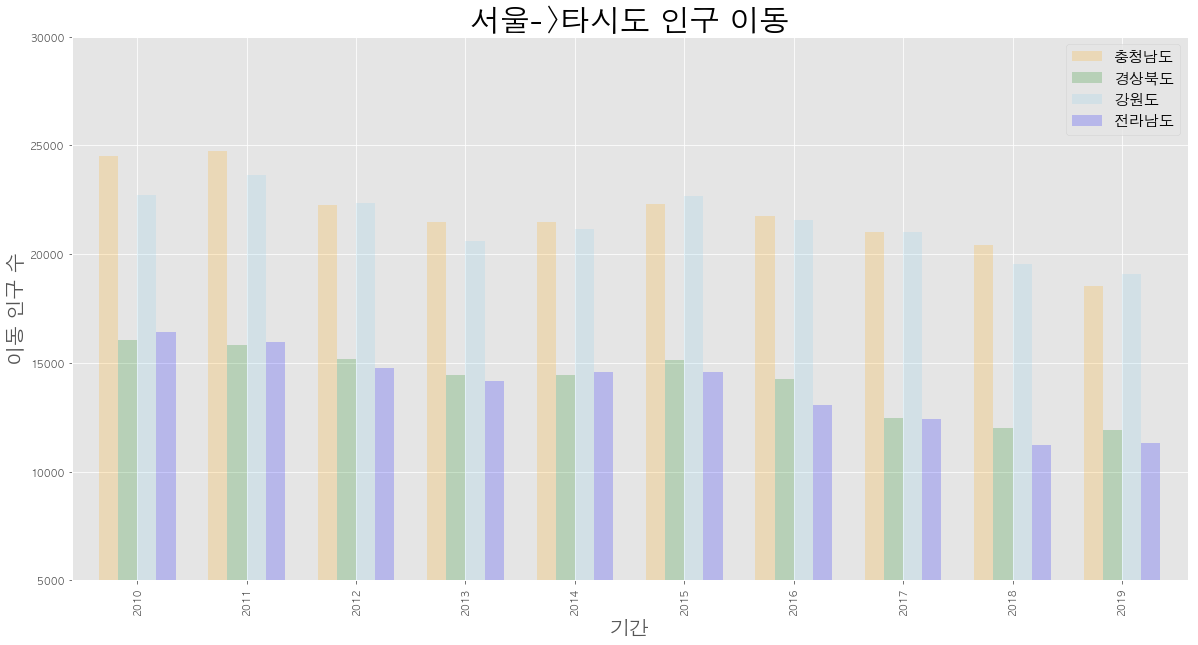

In [20]:
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 1970부터 2020까지 숫자를 문자로(str 함수)로 변환해서 리스트로 만든다
col_years = list(map(str, range(2010, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4 = df_4.transpose()

plt.style.use('ggplot')

df_4.index = df_4.index.map(int)

# df_4.plot을 통해 ax객체를 받아온다.
df_4.plot(kind='bar', width=0.7, color=['orange','green','skyblue','blue'], 
        alpha=0.2, figsize=(20,10))

plt.title('서울->타시도 인구 이동', size=30,weight='bold')
plt.ylabel('이동 인구 수', size=20)
plt.xlabel('기간', size=20)
plt.ylim(5000, 30000)
plt.legend(loc='best', fontsize=15)

plt.show()

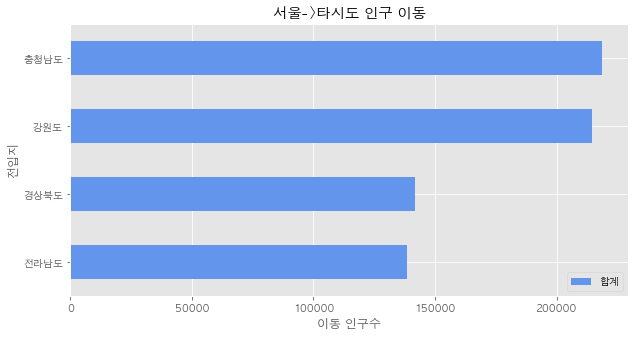

In [21]:
from matplotlib import rc
rc('font', family='AppleGothic')

mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시')
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul.rename({'전입지별':'전입지'}, axis=1, inplace=True)
df_seoul.set_index('전입지', inplace=True)

# 1970부터 2020까지 숫자를 문자로(str 함수)로 변환해서 리스트로 만든다
col_years = list(map(str, range(2010, 2020)))
df_4 = df_seoul.loc[['충청남도','경상북도','강원도','전라남도'], col_years]
df_4['합계'] = df_4.sum(axis=1)
df_total = df_4[['합계']].sort_values(by='합계', ascending=True)

plt.style.use('ggplot')

df_total.plot(kind='barh', width=0.5, color='cornflowerblue', figsize=(10,5))

plt.title('서울->타시도 인구 이동')
plt.ylabel('전입지')
plt.xlabel('이동 인구수')

plt.show()

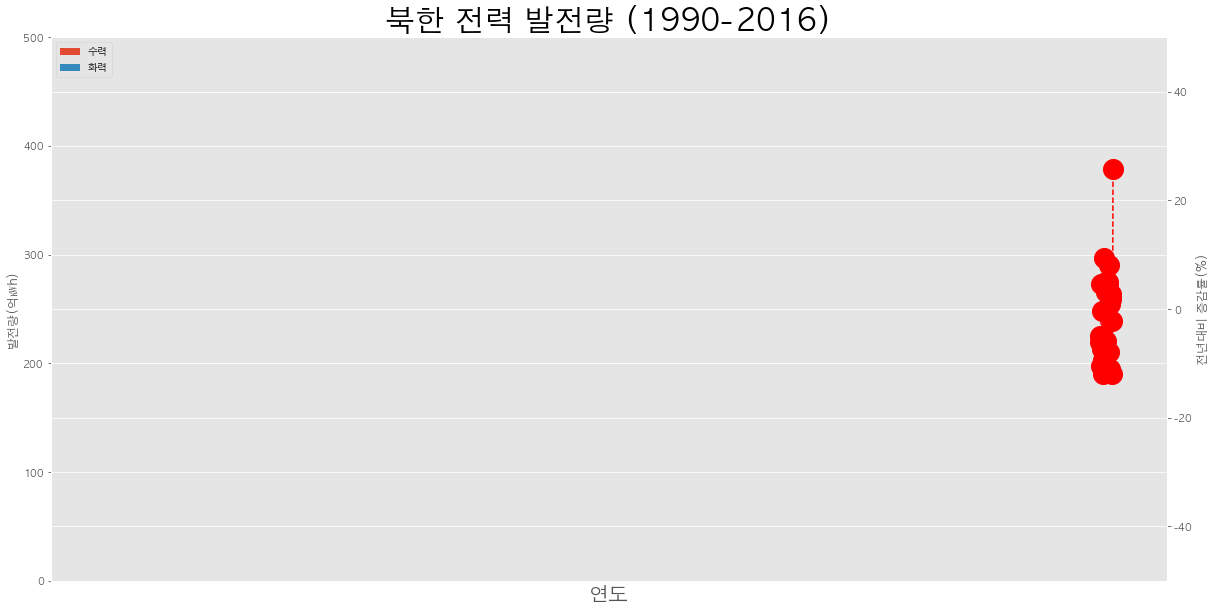

In [55]:
from matplotlib import rc
rc('font', family='AppleGothic')

plt.style.use('ggplot')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('./남북한발전전력량.xlsx', convert_float=True)
df = df.loc[5:9]  # 북한만 가져온다.

df.drop('전력량 (억㎾h)', axis='columns', inplace=True)
df.set_index('발전 전력별', inplace=True)
df = df.T

#증감률(변동률) 계산
df = df.rename(columns={'합계':'총발전량'})
df['총발전량 - 1년'] = df['총발전량'].shift(1)
df['증감률'] = ((df['총발전량'] / df['총발전량 - 1년']) - 1) * 100

# 2축 그래프 그리기
ax1 = df[['수력','화력']].plot(kind='bar', figsize=(20,10), width=0.7, stacked=True)
ax2 = ax1.twinx()
ax2.plot(df.index, df['증감률'], linestyle='--', marker='o', markersize=20,
        color='red', label='전년대비 증감률(%)')

ax1.set_xlim(len(df.index))
ax1.set_ylim(0, 500)
ax2.set_xlim(len(df.index))
ax2.set_ylim(-50, 50)


ax1.set_xlabel('연도', size=20)
ax1.set_ylabel('발전량(억㎾h)')
ax2.set_ylabel('전년대비 증감률(%)')

plt.title('북한 전력 발전량 (1990-2016)', size=30)
ax1.legend(loc='upper left')

plt.show()

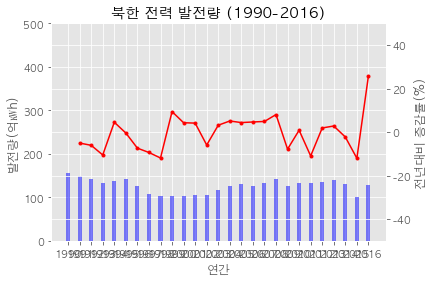

In [67]:
# 완성된 그래프는 아래와 같이 깔끔하게 보고서에 적용할 수 있는 모양으로 만들어 낼 수 있다. 더 다양한 그래프를 그리기 위해 참고 할 만한 사이트는 다음과 같다.

# http://matplotlib.org/users/screenshots.html


# 기본 Bar Chart 예제 2 ..................
import numpy as np
import matplotlib.pyplot as plt

y1_value = df['수력']
x_name= df.index
n_groups = len(x_name)

index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.5

plt.bar(index, y1_value, bar_width,
        tick_label=x_name, align='center',
        alpha=opacity, color='b', label='rainfall')

plt.xlabel('연간')
plt.ylabel('발전량(억㎾h)')
plt.title('북한 전력 발전량 (1990-2016)')
plt.xlim( -1, n_groups)
plt.ylim( 0, 500)

# twin axis ....
plt.twinx()
y2_value = df['증감률']
plt.plot(index, y2_value, 'r.-')
plt.ylabel('전년대비 증감률(%)')
plt.ylim(-50, 50)

plt.show()
